#### **Случайная величина имеет экспоненциальный закон распределения**
**p(x) = exp(-x) { [0,+∞) }**

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

### **Выборка объема n = 25**

In [65]:
n = 25
theta = 1

x_n = np.random.exponential(scale=theta, size=n)

print(*x_n, sep='\n')

0.577803224381016
0.6426978379261772
0.9741142850784907
0.36905278677753217
2.904138545691023
1.9481907663098936
0.30322037667626117
3.4686505764043107
0.3136281472299272
2.2093483265152565
0.4426662957589669
0.5896788132833781
0.33500215903528374
0.006734973875090293
2.1689339575331856
0.7404479501047767
0.7772706728204778
1.1405733705420693
1.5638186876767846
0.223716504067335
0.005117982966652104
1.3224594184505722
0.07250069510879568
0.04510651784398199
0.31325719879090896


### **a) Определить по выборке моду, медиану, размах, оценку коэффициента асимметрии.**

In [66]:
# Мода (если есть)

def get_mode(selection: np.array):  
    unique_x_n_counts = np.unique_counts(selection)
    max_mode = np.max(unique_x_n_counts[1])
    mask = unique_x_n_counts[1] == max_mode

    mode = unique_x_n_counts[0][mask]
    mode = mode[0] if len(mode) == 1 else None
    return mode

mode = get_mode(x_n)

print(f"Мода ( если есть выделяющаяся ) : {mode}")

# Медиана

def get_median(selection: np.array):
    sorted_selection = np.sort(selection)
    selection_len = len(selection)
    if selection_len%2==0:
        return 0.5*(sorted_selection[selection_len//2] + sorted_selection[selection_len//2-1])
    else:
        return sorted_selection[selection_len//2]
    
median = float(get_median(x_n))

print(f"Медиана: {median}")

# Размах

def get_range(selection: np.array):
    return np.max(selection) - np.min(selection)

range_ = float(get_range(x_n))

print(f"Размах: {range_}")

# Оценка коэффициента ассиметрии

def get_k_moment_estimation(selection: np.array, k: int):
    return np.sum(selection**k)/(len(selection))

def get_central_k_moment_estimation(selection: np.array, k: int):
    M_s = get_k_moment_estimation(selection, k=1)
    return np.sum((selection-M_s)**k)/(len(selection))

def get_asymmetry_coefficient_estimation(selection: np.array):
    return get_central_k_moment_estimation(selection, 3)/(get_central_k_moment_estimation(selection, 2)**(3/2))

print(f"Оценка Коэффициента ассиметрии: {get_asymmetry_coefficient_estimation(x_n)}")

Мода ( если есть выделяющаяся ) : None
Медиана: 0.5896788132833781
Размах: 3.463532593437659
Оценка Коэффициента ассиметрии: 1.2349735143562266


### **b) Построить эмпирическую функцию распределения, гистограмму и boxplot.**

(Проверка) Площадь под гистограммой = 1.0000000000


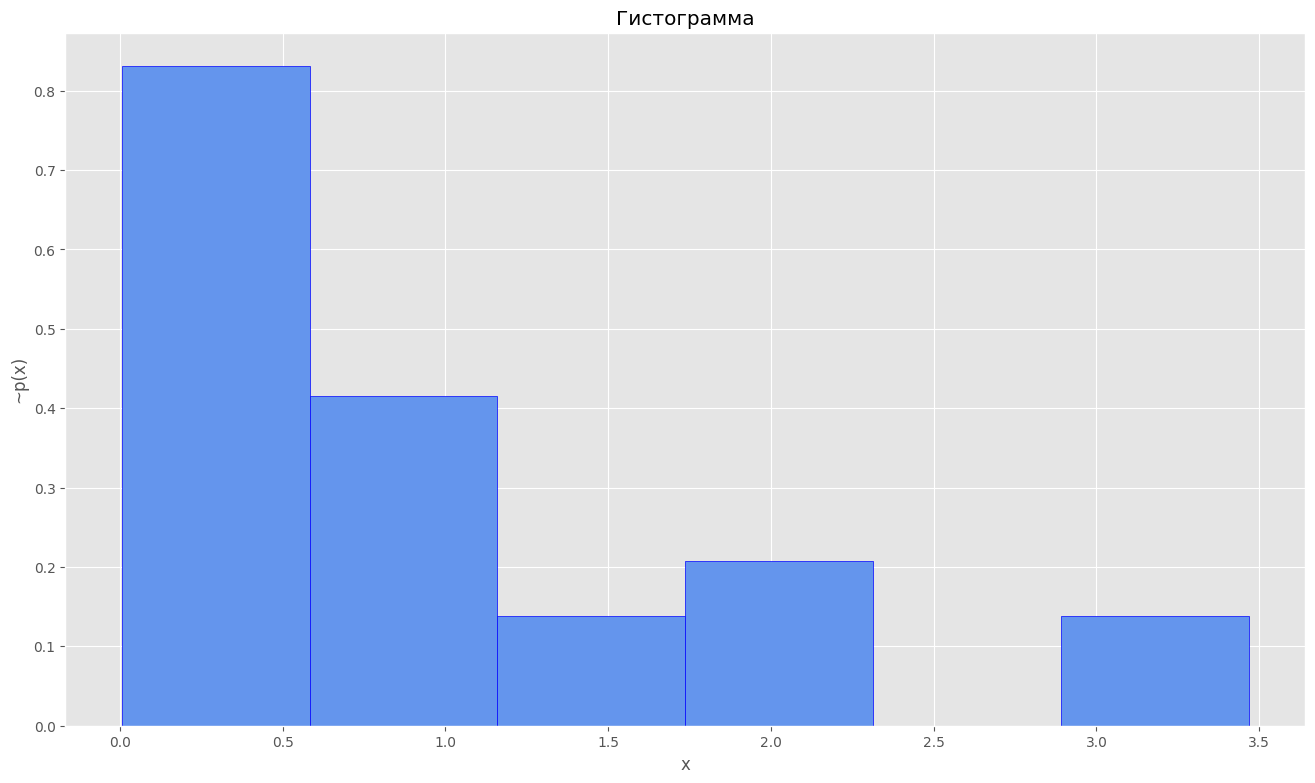

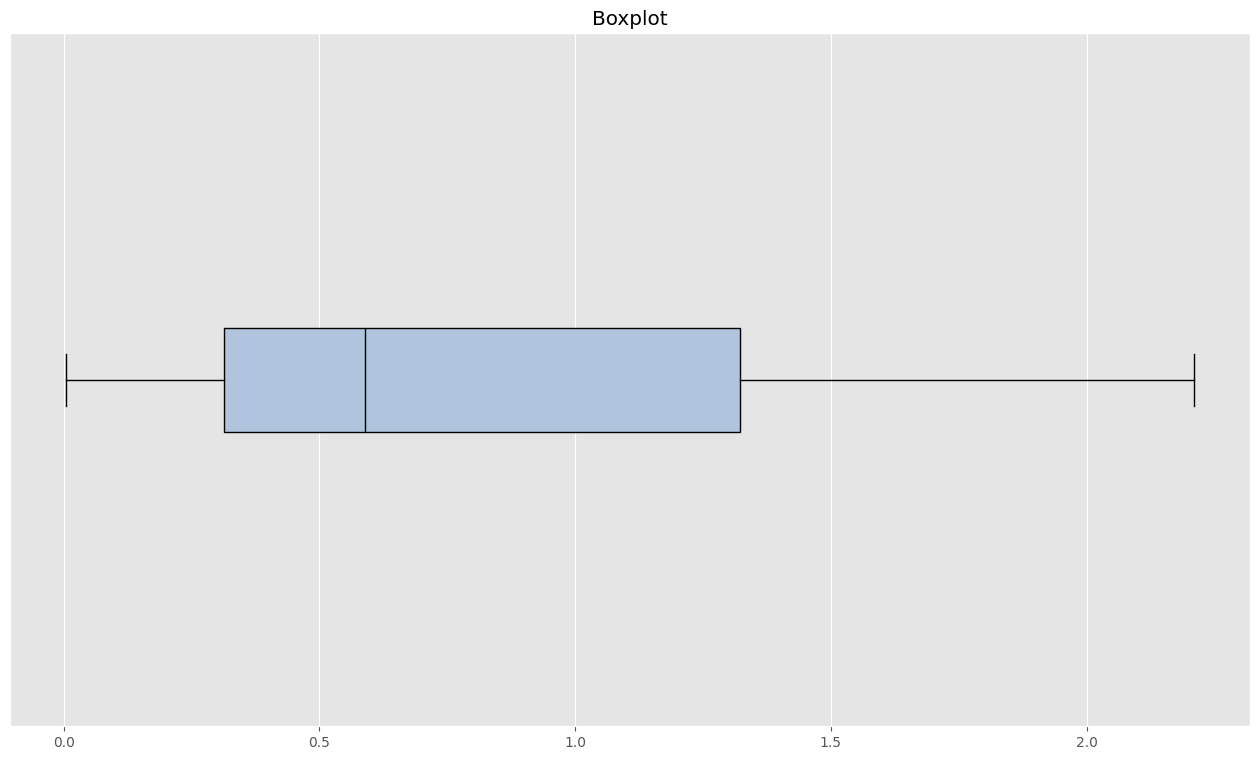

In [67]:
# Histagramm

plt.style.use("ggplot")
np.random.seed(49)

figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes


def make_hist(selection: np.array, filename: str, hist_name: str=""):
    n = len(selection)
    k = int(1 + np.round(np.log2(n)))
    delta_i = get_range(selection)/k
    
    start_p = np.min(selection)
    stop_p = np.max(selection)
    x_p = np.linspace(start_p, stop_p, k+1)

    y_p = []
    area = 0
    for i in range(len(x_p)-1):
        if i == len(x_p) - 2:
            mask = (x_p[i] <= selection) & (selection <= x_p[i+1])
        else:
            mask = (x_p[i] <= selection) & (selection < x_p[i+1])
        y_i = len(selection[mask])/(n*delta_i)
        y_p.append(y_i)
        area += delta_i*y_i

    print(f"(Проверка) Площадь под гистограммой = {area:.10f}")
    
    left = x_p[:-1] 
    axis.bar(
        left,
        y_p,
        (get_range(selection)/k),
        color="cornflowerblue",
        edgecolor="blue",
        align="edge",
        label = hist_name 
    )
    plt.xlabel('x')
    plt.ylabel('~p(x)')
    plt.title('Гистограмма')
    if(filename): plt.savefig(filename)

    return (x_p, y_p)

make_hist(x_n, "./b_hist")
plt.show()
plt.close()

# BoxPlot
figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes

axis.boxplot(
    x_n,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="k"),
    showfliers = False
)
axis.set_yticks([])
plt.title("Boxplot")
plt.savefig("./b_boxplot")
plt.show()
plt.close()

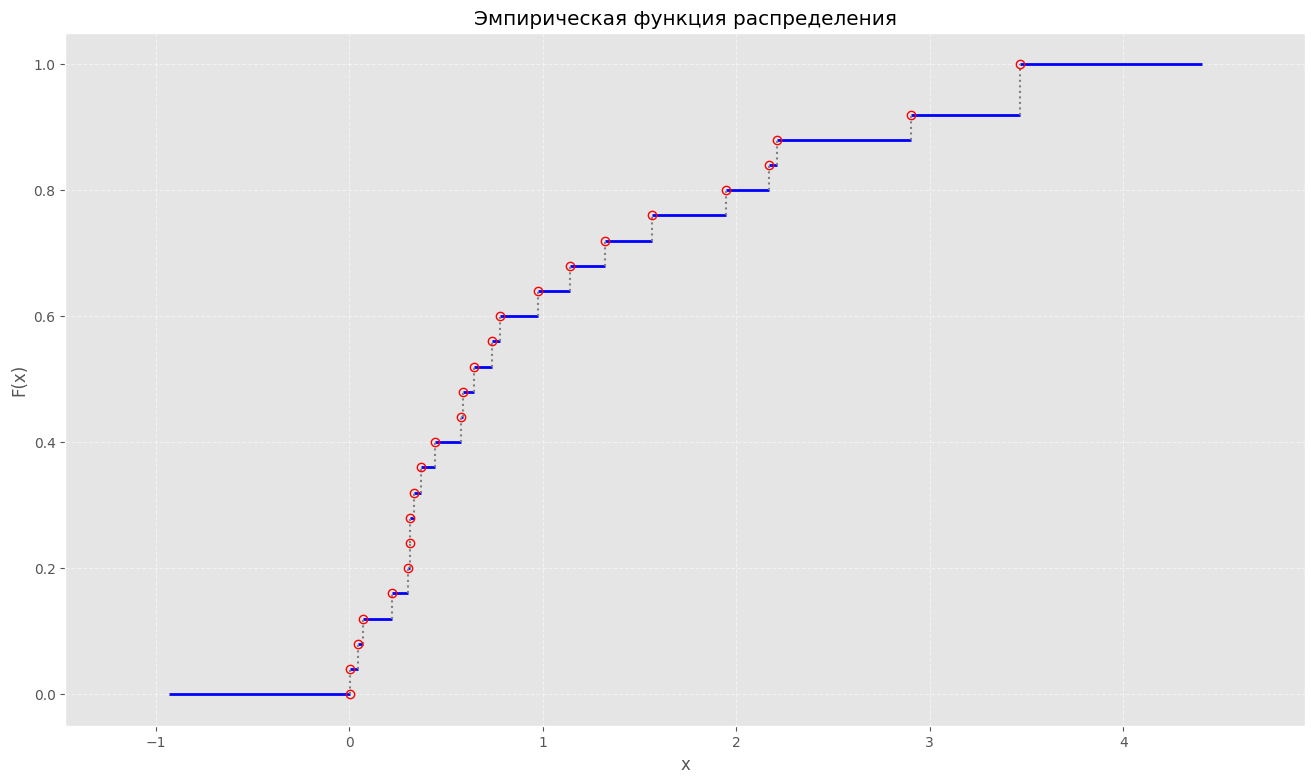

In [68]:
# Эмпирическая функция распределения

figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes

def empiric_fun(x: float, selection: np.array):
    return len(selection[selection < x])/len(selection)

def make_function_graph(selection: np.array):
    start_p = np.min(selection) - np.average(selection)
    stop_p = np.max(selection) + np.average(selection)
    
    sorted_sel = np.sort(selection)
    uniq = np.unique(sorted_sel)
    f_vals = np.array([empiric_fun(x, selection) for x in uniq])
    f_vals[-1] = 1.0  # гарантируем, что последняя точка на y=1
    
    plt.hlines(0, start_p, uniq[0], colors='blue', linewidth=2)
    for i in range(len(uniq)-1):
        plt.hlines(f_vals[i], uniq[i], uniq[i+1], colors='blue', linewidth=2)
    plt.hlines(1, uniq[-1], stop_p, colors='blue', linewidth=2)
    
    for i, x in enumerate(uniq):
        y_bottom = 0 if i == 0 else f_vals[i-1]
        plt.plot([x, x], [y_bottom, f_vals[i]], ':', color='gray', linewidth=1.5)
    
    for i in range(len(uniq)):
        plt.plot(uniq[i], f_vals[i], 'o', markerfacecolor='none', markeredgecolor='red', markersize=6)
    
    margin = (stop_p - start_p) * 0.1
    plt.xlim(start_p - margin, stop_p + margin)
    
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.ylim(-0.05, 1.05)
    plt.title('Эмпирическая функция распределения')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig("./b_emp_fun")

make_function_graph(x_n)
plt.show()
plt.close()

### **c) Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности.**

(Проверка) Площадь под гистограммой = 1.0000000000


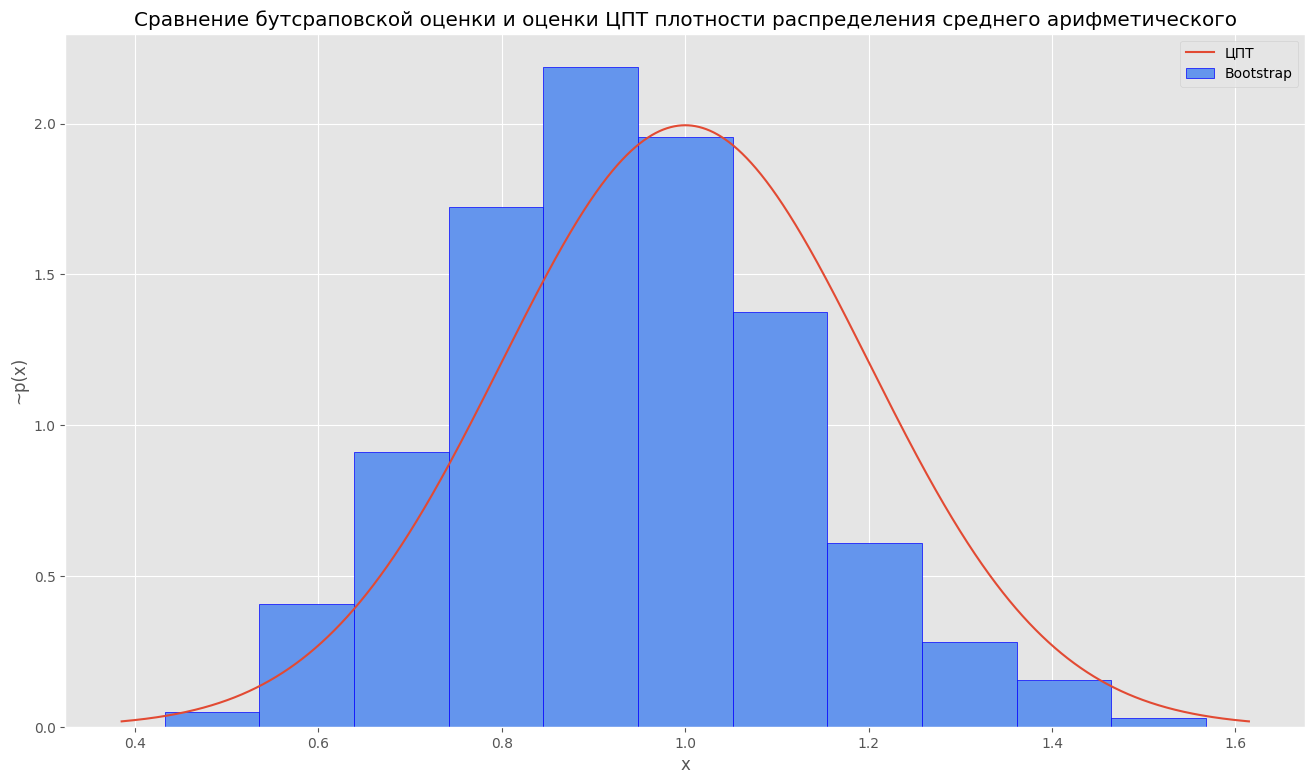

In [69]:
# Bootstrap
figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes


def gauss_distribution_density(x: float, mean: float, sigma_2: float):
    return 1/(np.sqrt(2*np.pi*sigma_2))*np.exp(-(x-mean)**2/(2*sigma_2))

def bootstrap_hist(selection: np.array, statistic: callable, N: int, filename: str):
    stat_selection = []
    selection_new = np.random.choice(selection, size=len(selection)*N)

    for i in range(0, len(selection)*N, len(selection)):
        stat_selection.append(statistic(selection_new[i:i+len(selection)]))
    left, y_p = make_hist(np.array(stat_selection), filename, "Bootstrap")

    return np.array(stat_selection), left, y_p

N = 1000

st_selection = bootstrap_hist(x_n, np.average, N, "")[0]

start_p = np.min(st_selection)- np.average(st_selection)*0.05
end_p = np.max(st_selection) + np.average(st_selection)*0.05

x_p = np.linspace(start_p, end_p, 10000)
sigma_2 = 1/n
mean = 1
y_p = gauss_distribution_density(x_p, mean, sigma_2)
_ = plt.plot(x_p, y_p, label='ЦПТ')
plt.title('Сравнение бутсраповской оценки и оценки ЦПТ плотности распределения среднего арифметического')
plt.legend()
plt.savefig("./c_bootstrap_CLT_compare")
plt.show()
plt.close()

### **d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1.**

(Проверка) Площадь под гистограммой = 1.0000000000
Оценка вероятности быть меньше 1 ( по гистограмме ): 0.344168856171168
Оценка вероятности быть меньше 1 ( по точкам ): 0.334


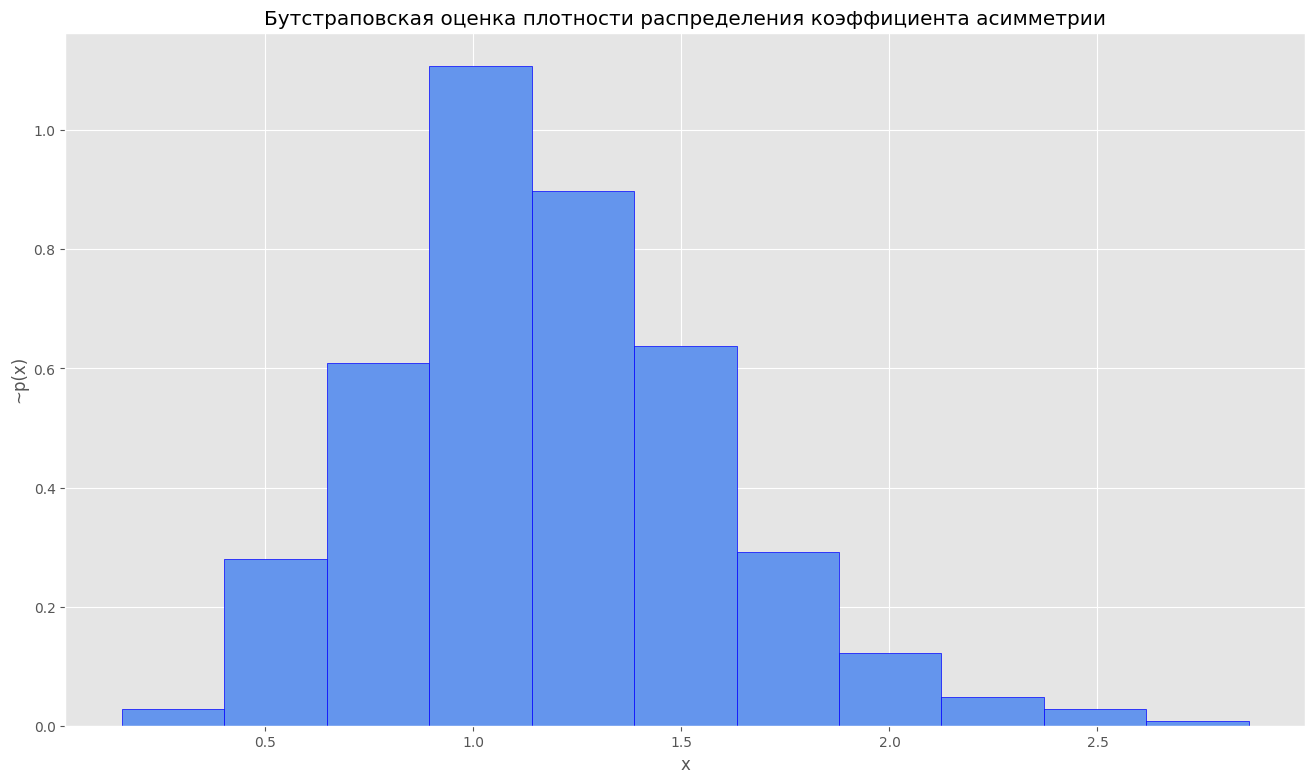

In [70]:
figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes

st_selection_2, edges, heights = bootstrap_hist(x_n, get_asymmetry_coefficient_estimation, N,  "")

# Оценка вероятности быть меньше 1

p_evaluation = 0
for i in range(len(heights)):
    if edges[i+1] <= 1:
        p_evaluation += heights[i] * (edges[i+1] - edges[i])
    elif edges[i] < 1 < edges[i+1]:
        p_evaluation += heights[i] * (1 - edges[i])
        break
    else:
        break
print(f"Оценка вероятности быть меньше 1 ( по гистограмме ): {p_evaluation}")
print(f"Оценка вероятности быть меньше 1 ( по точкам ): {len(st_selection_2[st_selection_2 < 1])/len(st_selection_2)}")
plt.title('Бутстраповская оценка плотности распределения коэффициента асимметрии')
plt.savefig("./d_bootstrap_asymm_coef")
plt.show()
plt.close()

### **e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности.**

(Проверка) Площадь под гистограммой = 1.0000000000


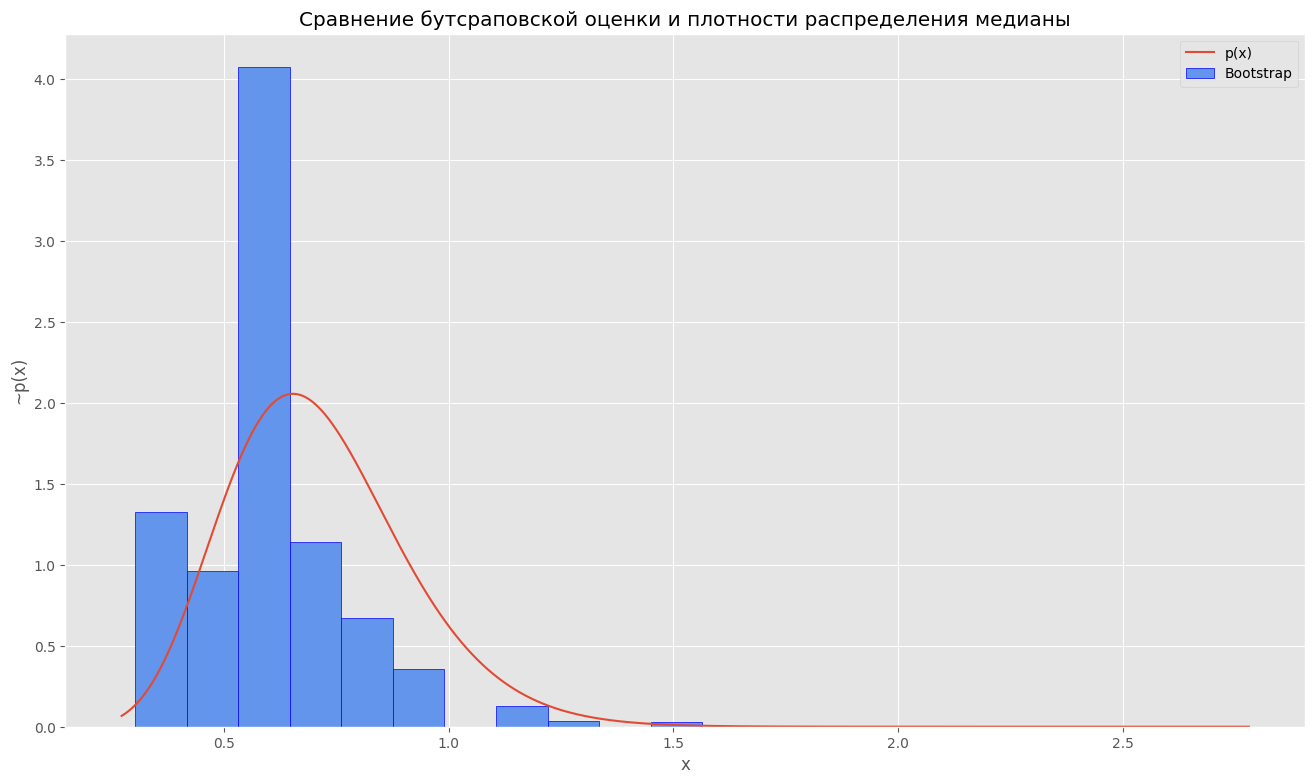

In [71]:
def exponential_distribution(x: float):
    if (x <= 0):
        return 0
    else:
        return (1-np.exp(-1*x))

def exponential_density(x: float):
    if (x <= 0):
        return 0
    else:
        return (np.exp(-1*x))

# Слагаемые полученны почленным дифф. формулы с лекции для функции распределения k-ой порядковой статистики
def k_ordinal_statistics_density(F: callable, p: callable, n: int, k: int, x: float):
    summ_ = 0
    F_x = F(x)
    p_x = p(x)
    for i in range(k, n+1):
        summ_ += comb(n, i) * p_x * (F_x**(i-1)) * ((1-F_x)**(n-i-1)) * (i*(1-F_x) - (n-i)*F_x) 
    return summ_

figure, axis = plt.subplots(figsize=(16, 9))
axis: plt.Axes

st_selection_3, _, _ = bootstrap_hist(x_n, get_median, N, "")

start_p = np.min(st_selection_3)- np.average(st_selection_3)*0.05
end_p = np.max(st_selection_3) + np.average(st_selection_3)*2

x_p_ = np.linspace(start_p, end_p, 10000)
y_p_ = []

k = n//2 + 1

for i in range(len(x_p_)):
    y_p_.append(k_ordinal_statistics_density(exponential_distribution, exponential_density, n, k, x_p_[i]))
_ = plt.plot(x_p_, y_p_, label = "p(x)")

plt.title('Сравнение бутсраповской оценки и плотности распределения медианы')
plt.legend()
plt.savefig("./e_bootstrap_median_compare")
plt.show()
plt.close()